In [1]:
import nibabel as nib
import nilearn.plotting as plotting
import nilearn.image as image
import numpy as np

import os
# os.environ["CUDA_VISIBLE_DEVICES"] = "3"

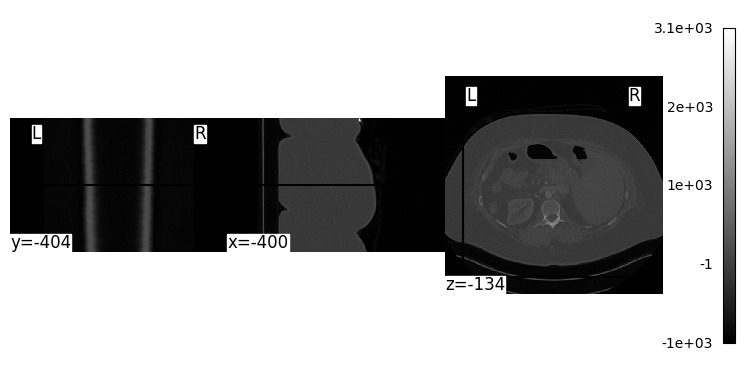

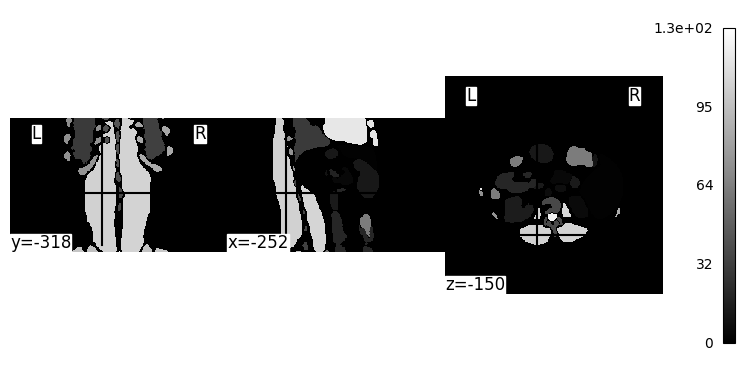

In [9]:
scan_path = '/PHShome/yl535/project/python/datasets/AbdomenCT-1K-Image/images/Case_00001_0000.nii.gz'
mask_path = '/PHShome/yl535/project/python/datasets/AbdomenCT-1K-Image/seg_mask/Case_00001_0000/Case_00001_0000_lab.nii.gz'

plotting.plot_img(scan_path)
plotting.plot_img(mask_path)

# img = nib.load(scan_path)
# print(f"Original Scan Shape: {img.shape}") 

# # --- SOLUTION: Select the first modality (e.g., index 0) ---
# # index 0 is usually FLAIR in BRATS data
# first_modality = image.index_img(scan_path, 0)

# print(f"Sliced Shape: {first_modality.shape}") # Should be (240, 240, 155)

# # Now you can plot it
# plotting.plot_img(first_modality, title="Modality 0 (FLAIR)")

# # If you want to see a specific slice (cut_coords)
# plotting.plot_anat(first_modality, cut_coords=(100, 100, 70), title="Anatomical View")

# # The mask is usually already 3D, so this line likely works fine as is:
# plotting.plot_roi(mask_path, bg_img=first_modality, title="Tumour Mask")

# plotting.plot_roi(
#     roi_img=mask_path, 
#     bg_img=first_modality, 
#     title="Tumor Mask Overlay (FLAIR)",
#     cmap='Paired',       # 'Paired' gives distinct colors for different labels
#     draw_cross=False     # Removes the target crosshairs for a cleaner view
# )

In [6]:
img = image.load_img(scan_path)
data = img.get_fdata()
print(f"Shape: {data.shape}, Type: {data.dtype}")

mask_img = image.load_img(mask_path)
data = mask_img.get_fdata()
print(f"Shape: {data.shape}, Type: {data.dtype}")
print(f"Unique mask values: {np.unique(data)}")
# print unique values with counts 
(unique, counts) = np.unique(data, return_counts=True)
# print out the zip of unique values and counts
print(list(zip(unique, counts)))

Shape: (512, 512, 83), Type: float64
Shape: (512, 512, 128), Type: float64
Unique mask values: [  0.   1.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.  14.
  17.  19.  28.  29.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.
  41.  54.  58.  59.  60.  61.  62.  67.  68.  69.  70.  71.  72.  73.
  74.  80.  81.  82.  83.  84.  85.  86.  93.  95.  96. 104. 105. 106.
 107. 114. 115. 121. 122. 125.]
[(0.0, 28297044), (1.0, 1170661), (3.0, 144558), (4.0, 65908), (5.0, 129604), (6.0, 31642), (7.0, 53026), (8.0, 1806), (9.0, 2027), (10.0, 53285), (11.0, 5248), (12.0, 315427), (13.0, 52024), (14.0, 140778), (17.0, 23198), (19.0, 166464), (28.0, 45157), (29.0, 498548), (31.0, 65169), (32.0, 578793), (33.0, 31914), (34.0, 45046), (35.0, 41294), (36.0, 38760), (37.0, 34042), (38.0, 29646), (39.0, 27428), (40.0, 7453), (41.0, 4), (54.0, 8), (58.0, 1576), (59.0, 1540), (60.0, 2168), (61.0, 2010), (62.0, 462884), (67.0, 4), (68.0, 434), (69.0, 3730), (70.0, 5041), (71.0, 6999), (72.0, 98

Resampling mask to match scan geometry...


/tmp/ipykernel_2579019/3399058107.py:5: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  resampled_mask = image.resample_to_img(
/tmp/ipykernel_2579019/3399058107.py:5: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  resampled_mask = image.resample_to_img(


Old Mask Shape: (512, 512, 128)
New Mask Shape: (512, 512, 83)
Plotting Label 125...


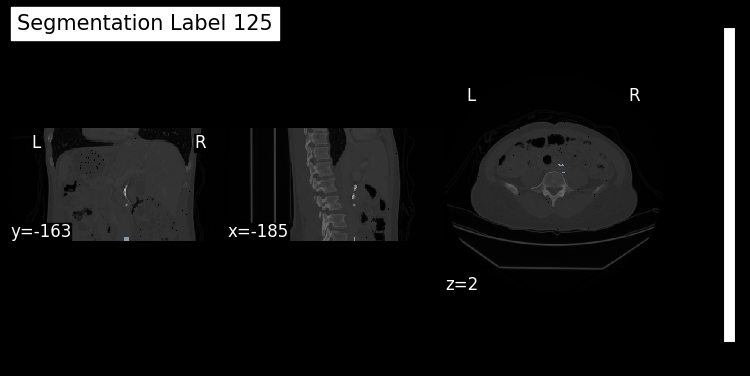

In [8]:
# --- STEP 1: FIX DIMENSION MISMATCH ---
# We use 'nearest' interpolation to preserve integer labels (0, 1, 2). 
# Default interpolation would blend them (creating 1.5), which ruins masks.
print("Resampling mask to match scan geometry...")
resampled_mask = image.resample_to_img(
    source_img=mask_path, 
    target_img=scan_path, 
    interpolation='nearest' 
)

# Verify the fix
print(f"Old Mask Shape: {nib.load(mask_path).shape}")
print(f"New Mask Shape: {resampled_mask.shape}") # Should now match Scan (512, 512, 83)


# --- STEP 2: EXTRACT "FIRST" MASK (LABEL 1) ---
# Your unique values show Label 1 has ~1.1 million pixels (likely a large organ like Liver)
target_label = 125

# Get data from the fixed mask
mask_data = resampled_mask.get_fdata()

# Create a binary mask: 1 where data is target_label, 0 elsewhere
binary_mask_data = (mask_data == target_label).astype(np.int8)

# Convert back to Nifti image so nilearn can read it
# We must use the affine from the resampled mask
binary_mask_img = nib.Nifti1Image(binary_mask_data, resampled_mask.affine)


# --- STEP 3: PLOT ---
print(f"Plotting Label {target_label}...")

plotting.plot_roi(
    roi_img=binary_mask_img, 
    bg_img=scan_path, 
    title=f"Segmentation Label {target_label}",
    cmap='Paired',
    draw_cross=False
)

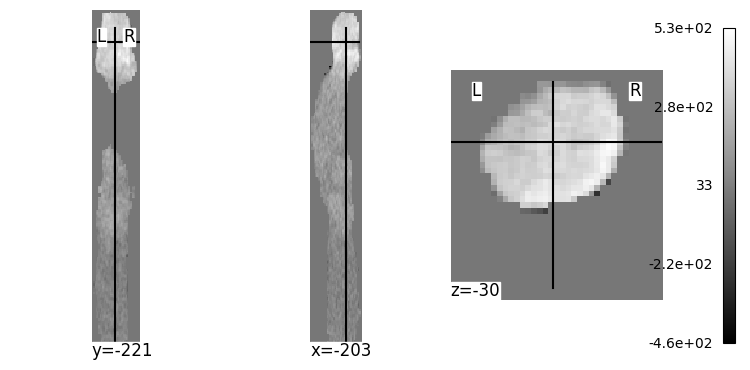

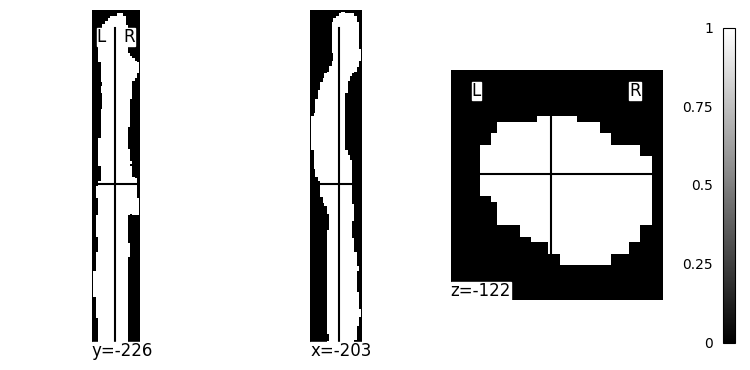

In [10]:
scan_path = '/PHShome/yl535/project/python/datasets/MSD/AbdomenCT-1K-Image/segmented/Case_00001_0000_7.nii.gz'
mask_path = '/PHShome/yl535/project/python/datasets/MSD/AbdomenCT-1K-Image/segmented/Case_00001_0000_7_mask.nii.gz'

plotting.plot_img(scan_path)
plotting.plot_img(mask_path)
